In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.special import expit

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 14})

SEED = 314159
TRAIN_TEST_SPLIT = 0.80

data_path = "C:\Slava\spbu_ml_2026\data"

<>:22: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:22: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\Slava Bek\AppData\Local\Temp\ipykernel_17368\1628770495.py:22: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  data_path = "C:\Slava\spbu_ml_2026\data"


# Калибровка вероятностей

Часто при обучении моделей для бинарной классификации хочется получать не только предсказанную метку класса, но и вероятность положительного класса. Предсказанная вероятность может служить как мера уверенности нашего алгоритма. Также это позволяет сравнивать две модели, у которых одинаковые метрики точности. Этот тип метрик конкретно используется в высокорисковых приложениях, позволяя нам не рассматривать результаты модели как реальные вероятности, а вместо этого выходить за рамки необработанных результатов и предотвращать плохое принятие решений или ложную интерпретацию.

В задаче бинарной классификации откалиброванным алгоритмом называют такой алгоритм, для которого доля положительных примеров (на основе реальных меток классов) для предсказаний в окрестности произвольной вероятности $\hat p$ совпадает с этим значением $p$. Например, если взять объекты, для которых предсказанные вероятности близки к 0.7, то окажется, что среди них 70\% принадлежат положительному классу.
На математическом языке это выглядит так: если $\hat p$  — предсказанная вероятность класса 1, то $P(y=1|q(x_i)=\hat p)=\hat p$.

Однако некоторые алгоритмы не выдают корректные вероятности классов. В таком случае вероятности модели нужно калибровать.

Для визуализации откалиброванности алгоритма можно построить калибровочную кривую. На этой кривой абсцисса точки соответствуют значению $p$ (предсказаний алгоритма), а ордината соответствует доле примеров, для которых алгоритм предсказал вероятность, близкую к $p$. В идеальном случае эта кривая совпадает с прямой $y = x$. 

Чаще всего  $\hat p$ - это какие-то вещественные числа, которые будут разными для разных $y_i$. Для того, чтобы оценить именно вероятности, отрезок $[0, 1]$ можно разбить на бины, и для каждого бина вычислить долю класса 1 и,соответственно, среднюю предсказанную вероятность.

Пример диаграммы калибровки: 

![calib_1](../additional_materials/images/calib_1.png)


У идеально откалиброванной модели зеленая и розовая линии должны совпадать. Однако в нашем случае модель завышает свою оценку. Как отделить положительные примеры от отрицательных (дать дискретный класс)? Обычно пользуются порогом (логично сделать 0.5). Но нам придется сдвинуть порог вправо - так, чтобы разбить зеленый график пополам по вертикали.

Часто картинка иная. В таком случае говорят о слишком увернной модели (overconfident) или неуверенной (underconfident). В первом случае молдель предсказывает вероятности ближе к экстремальным, ченм стоит (0.1 вместо 0.2 и 0.9 вместо 0.1), во втором же наоборот, сводит все вероятности к центру интервала.

![calib_2](../additional_materials/images/calib_2.png)

Часто слишком большой уверенностью грешат нейросети, так как их учат именно на метках классов. Способ с этим бороться - Label smoothing, когда вместо метки класса модели дают слегка сглаженное значение (0.9 вместо 1, и т.д.). Альтернативный путь - hard samples mining, когда мы заставляем модель больше обращать внимания на объекты ближе к границе разделения.

Второй же случай возникает, если мы, наоборот, слишком сильно уделяем внимание границе. Это часто происходит в SVM или бэггинге.

Ниже на синтетическом примере посмотрим на типичные калибровочные кривые для overconfident и underconfident моделей: генерируем данные с нелинейной границей, получаем «предсказания» и искусственно искажаем их к экстремумам или к центру интервала. Кроме того, рассмотрим случай, когда модель предсказывает отношение классов, не зависящее от х.

In [2]:
from sklearn.datasets import make_moons

X_syn, y_syn = make_moons(n_samples=2000, noise=0.25, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X_syn, y_syn, test_size=0.4, random_state=SEED)
clf_syn = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
p_real = np.clip(clf_syn.predict_proba(X_te)[:, 1], 1e-6, 1 - 1e-6)

def logit(p: np.ndarray) -> np.ndarray:
    return np.log(p / (1 - p))
    
# to get new probabilities we need to make more strict logits and then return back to probas
p_over = 1. / (1 + np.exp(-5 * logit(p_real))) 
p_under = 0.5 + 0.35 * (p_real - 0.5)
p_constant = np.full_like(p_real, y_te.mean())

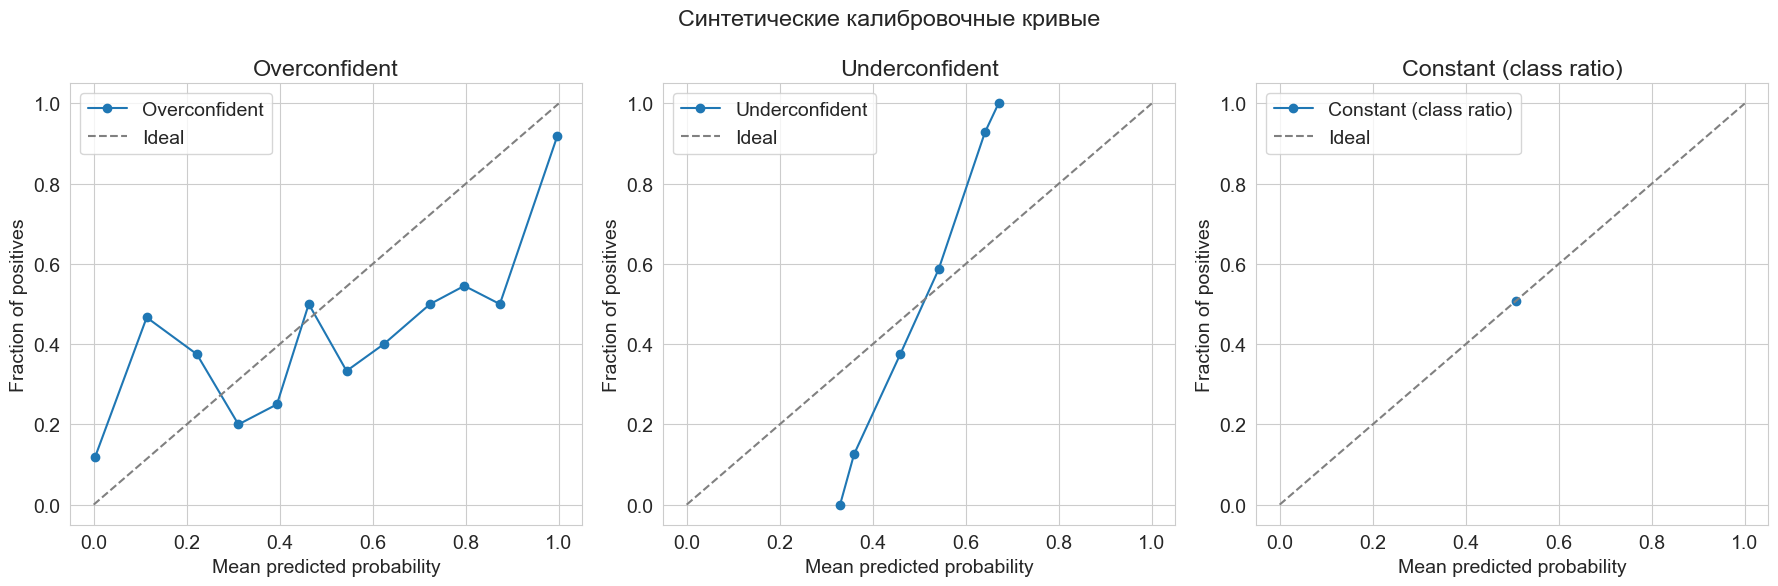

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for ax, probs, label in zip(axs, [p_over, p_under, p_constant], ['Overconfident', 'Underconfident', 'Constant (class ratio)']):
    t, p = calibration_curve(y_te, probs, n_bins=12)
    ax.plot(p, t, marker='o', label=label)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(label)
    ax.legend()
plt.suptitle('Синтетические калибровочные кривые')
plt.tight_layout()
plt.show()

In [4]:
data = pd.read_csv(data_path + '/' + 'riceClassification.csv')

Отмасштабируем данные и подготовим трейн и тест.

In [5]:
X = data.drop(columns=['id', 'Class'])
y = data.Class

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=999)
scaler = StandardScaler().fit(X_train, y_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

**Задание**: Оцените сбалансированность классов

In [9]:
print(y.value_counts())
print((y.value_counts(normalize=True) * 100).round(2))

Class
1    9985
0    8200
Name: count, dtype: int64
Class
1    54.91
0    45.09
Name: proportion, dtype: float64


In [13]:
print("Train:", y_train.value_counts().to_dict())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("Test:", y_test.value_counts().to_dict())
print((y_test.value_counts(normalize=True) * 100).round(2))

Train: {1: 5995, 0: 4916}
Class
1    54.94
0    45.06
Name: proportion, dtype: float64
Test: {1: 3990, 0: 3284}
Class
1    54.85
0    45.15
Name: proportion, dtype: float64


Обучим метод опорных векторов (SVC — Support Vector Classification) и логистическую регрессию, в качестве метрики возьмем ROC-AUC. Для сравнения также посмотрим на градиентный бустинг.
В качестве скоров будем рассматривать выход decision_function. Этот метод возвращает confidence score для семплов и пропорционален расстоянию до разделяющей гиперплоскости, взятого со знаком. Он вернет матрицу размера (n_samples, n_classes). В бинарном случае, будет возвращен скор для класса 1.

Вопрос: Какая формула для decision function у логистической регрессии?

Decision function в логистической регрессии:
f(x) = w^T x + b

Вероятность класса:
P(y=1 | x) = 1 / (1 + e^{-f(x)})

In [14]:
svc = LinearSVC(max_iter=100000, C=0.1).fit(X_train, y_train)
svc_pred = svc.decision_function(X_test)
print('SVC ROC-AUC:', roc_auc_score(y_test, svc_pred))

SVC ROC-AUC: 0.9991453206707389


In [15]:
svc_pred

array([ 3.25919713,  1.95223252,  1.93751674, ...,  0.46630054,
        2.95728847, -1.77506552], shape=(7274,))

In [16]:
svc.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], shape=(7274,))

In [17]:
print('SVC ROC-AUC (on predictions):', roc_auc_score(y_test, svc.predict(X_test)))

SVC ROC-AUC (on predictions): 0.9894067537906887


In [18]:
svc_proba = (svc_pred - svc_pred.min()) / (svc_pred.max() - svc_pred.min())
svc_proba

array([0.71871443, 0.60165813, 0.60034014, ..., 0.4685729 , 0.69167444,
       0.26782836], shape=(7274,))

In [19]:
lr = LogisticRegression(max_iter=100000, C=0.1).fit(X_train, y_train)
lr_pred = lr.decision_function(X_test)
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, lr_pred))

Logistic regression ROC-AUC: 0.9990017675125695


In [20]:
gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=SEED).fit(X_train, y_train)
gb_pred = gb.decision_function(X_test) # gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, gb_pred))

Gradient Boosting ROC-AUC: 0.9983573809676445


У случайного леса нет метода decision_function, поэтому просто посмотрим на точность.

In [21]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED).fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, rf_pred))

Random Forest ROC-AUC: 0.9991008275866279


In [22]:
lr.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], shape=(7274,))

In [23]:
lr.predict_proba(X_test)

array([[7.52180938e-05, 9.99924782e-01],
       [2.37484102e-03, 9.97625159e-01],
       [4.28557243e-03, 9.95714428e-01],
       ...,
       [1.72933989e-01, 8.27066011e-01],
       [2.10618110e-04, 9.99789382e-01],
       [9.98955458e-01, 1.04454161e-03]], shape=(7274, 2))

In [24]:
lr.classes_

array([0, 1])

Судя по метрикам, мы практически идеально предсказываем класс всеми моделями.

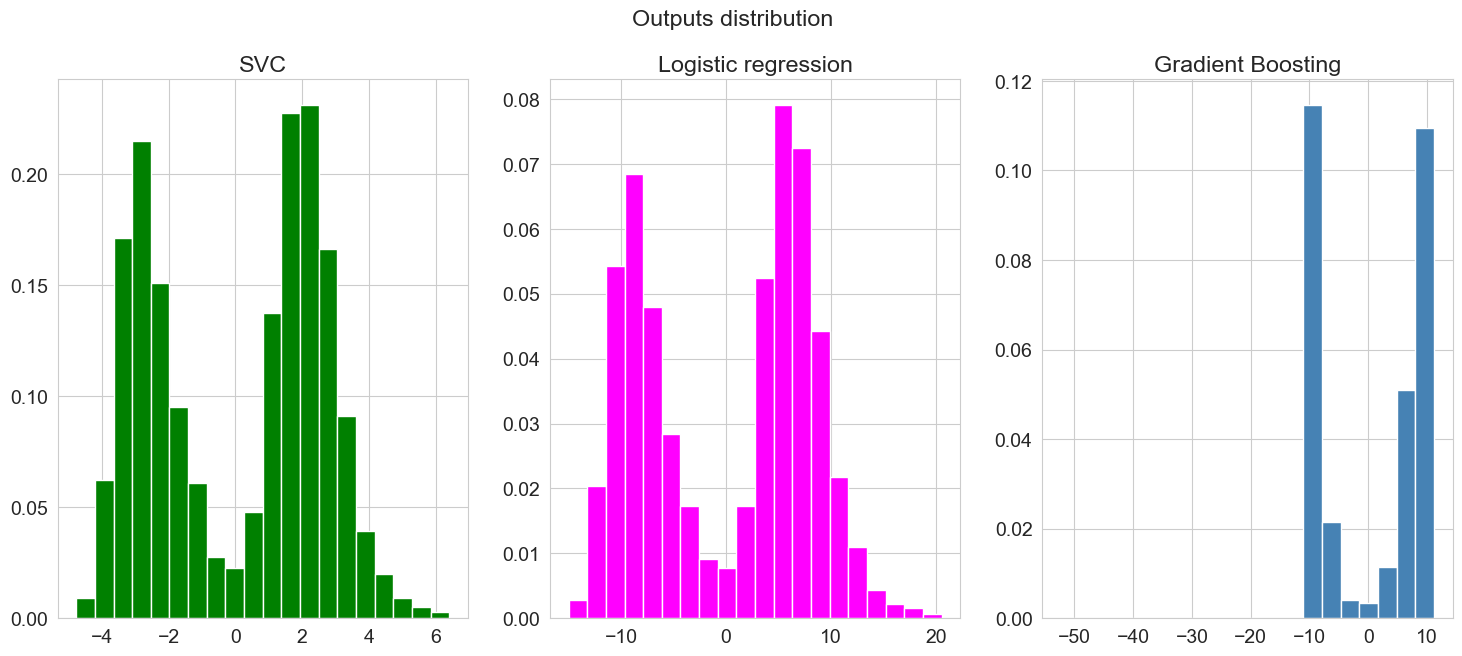

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(18, 7))

axs[0].hist(svc_pred, bins=20, color='green', density='True')
axs[1].hist(lr_pred, bins=20, color='magenta', density='True')
axs[2].hist(gb_pred, bins=20, color='steelblue', density='True')

axs[0].set_title('SVC')
axs[1].set_title('Logistic regression')
axs[2].set_title('Gradient Boosting')

plt.suptitle('Outputs distribution')
plt.show()

Мы видим, что скоры могут принимать любые вещественные значения. Но для оценивания вероятностей нам нужно перевести их в промежуток 
$[0,1]$. С логистической регрессией несложно: можно добавить сигмоиду или софтмакс, ведь модель и обучалась так, чтобы $\sigma (W^Tx)$
 приближало вероятности. Для SVC у нас нет такой опции, поэтому воспользуемся масштабированием через минимум-максимум.

Вопрос: а как вычисляются вероятности для бустинга?

В бустинге (с logloss) считаются сырые скоры F(x) как сумму деревьев, а затем переводит их в вероятности через сигмоиду:

Вероятности:
P(y=1 | x) = 1 / (1 + e^{-F(x)})

То есть бустинг аппроксимирует логиты, а сигмоида даёт вероятность

In [26]:
svc_pred = (svc_pred - svc_pred.min()) / (svc_pred.max() - svc_pred.min())
lr_pred = lr.predict_proba(X_test)[:, 1]
gb_pred = gb.predict_proba(X_test)[:, 1]
rf_pred = rf.predict_proba(X_test)[:, 1]

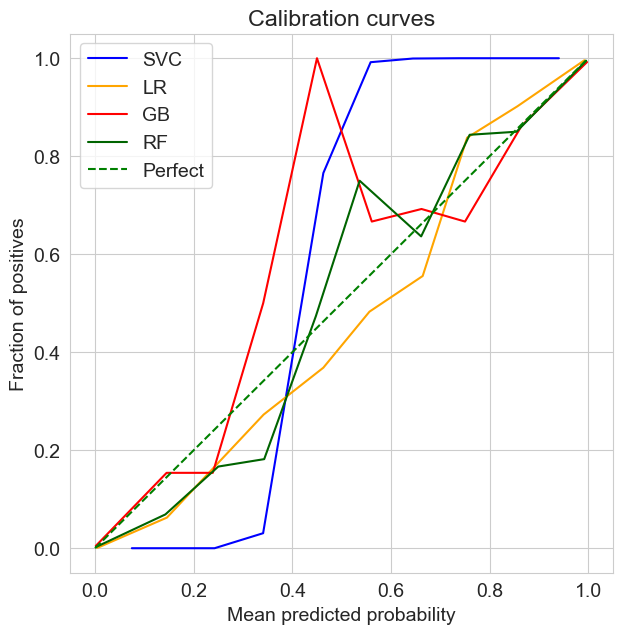

In [ ]:
plt.figure(figsize=(7, 7))

svc_true_prob, svc_pred_prob = calibration_curve(y_test, svc_pred, n_bins=10)
lr_true_prob, lr_pred_prob = calibration_curve(y_test, lr_pred, n_bins=10)
gb_true_prob, gb_pred_prob = calibration_curve(y_test, gb_pred, n_bins=10)
rf_true_prob, rf_pred_prob = calibration_curve(y_test, rf_pred, n_bins=10)

plt.plot(svc_pred_prob, svc_true_prob, label='SVC', color='blue')
plt.plot(lr_pred_prob, lr_true_prob, label='LR', color='orange')
plt.plot(gb_pred_prob, gb_true_prob, label='GB', color='red')
plt.plot(rf_pred_prob, rf_true_prob, label='RF', color='darkgreen')
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='green')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves')
plt.legend()
plt.show()

Мы видим, что кривая для логистической регрессии неплохо приближает диагональ, при этом в бустинге можно вообразить чрезмерную уверенность. С SVC все гораздо хуже. Но попробуем откалибровать модели разными способами.

Что интересно с ансамблями: у них есть явный горб посередине интервала. Это значит, что моделям в принципе сложновато предсказывать крайние значения вероятностей. Хорошее объяснение этому дано в [статье](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf), цитата из нее: 
> Methods such as bagging and random forests that average predictions from a base set of models can have difficulty making predictions near 0 and 1 because variance in the underlying base models will bias predictions that should be near zero or one away from these values. Because predictions are restricted to the interval [0,1], errors caused by variance tend to be one-sided near zero and one. 

> For example, if a model should predict $p=0$ for a case, the only way bagging can achieve this is if all bagged trees predict zero. If we add noise to the trees that bagging is averaging over, this noise will cause some trees to predict values larger than 0 for this case, thus moving the average prediction of the bagged ensemble away from 0. We observe this effect most strongly with random forests because the base-level trees trained with random forests have relatively high variance due to feature subsetting.”

Другой способ визуализировать то же самое - диаграмма надёжности (reliability diagram):

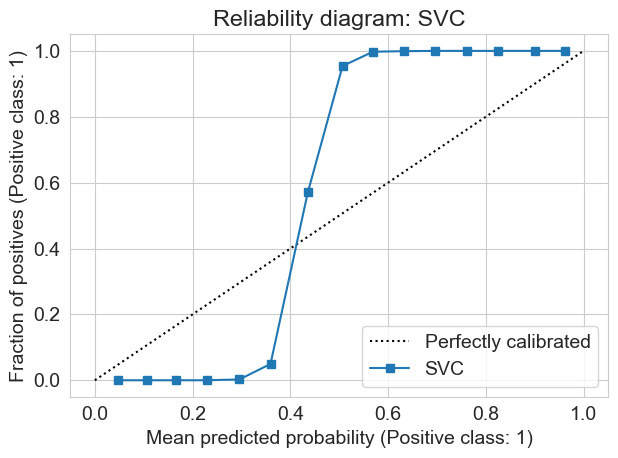

In [28]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test, svc_pred, n_bins=15, name='SVC')
plt.title('Reliability diagram: SVC')
plt.tight_layout()
plt.show()

**Задание**: Постройте гистограмму предсказанных вероятностей для двух классификаторов.

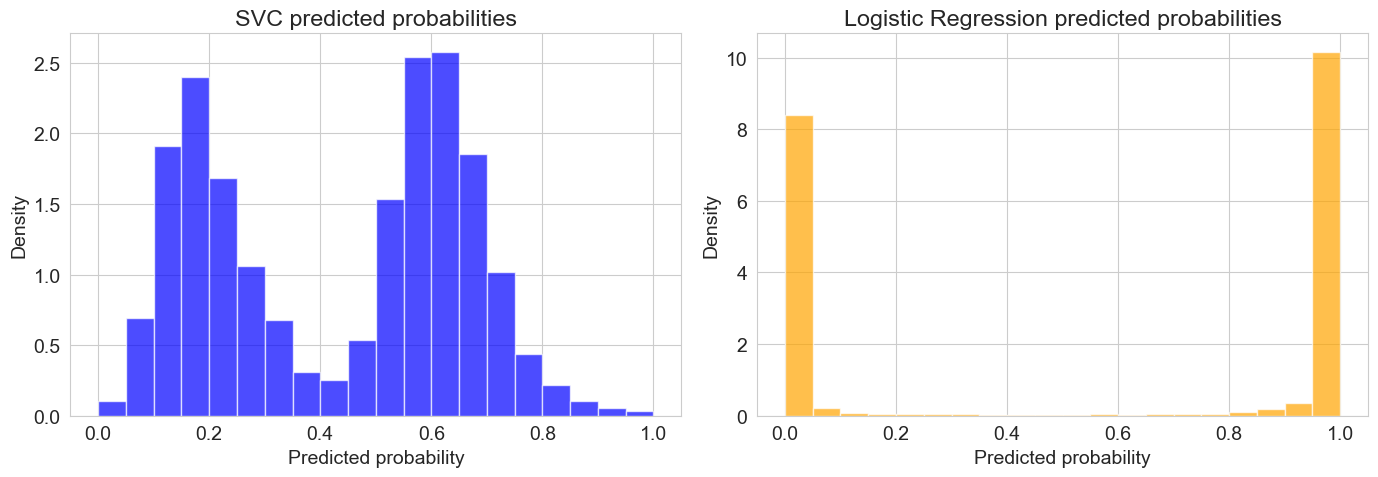

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].hist(svc_pred, bins=20, color='blue', alpha=0.7, density=True)
axs[0].set_title('SVC predicted probabilities')
axs[0].set_xlabel('Predicted probability')
axs[0].set_ylabel('Density')

axs[1].hist(lr_pred, bins=20, color='orange', alpha=0.7, density=True)
axs[1].set_title('Logistic Regression predicted probabilities')
axs[1].set_xlabel('Predicted probability')
axs[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

# Калибровка Платта
Пусть наш алгоритм выдаёт значения $f(x)$ (могут не быть вероятностями). Тогда итоговая вероятность строится как:

$$P(y = 1 | x) = \frac{1}{1+\exp (af(x) + b)},$$

где $a, b$ -- скалярные параметры. Эти параметры настраиваются методом максимума правдоподобия (минимизируя логистическую функцию потерь):
$$- \sum_{i=1}^N[y_i \log{(\sigma(af(x_i)+b))} + (1 - y_i) \log{(1-\sigma(af(x_i)+b))}] \to min_{a,b}$$

Алгоритм: на выходах $f(x)$ базовой модели обучается логистическая регрессия без регуляризации; откалиброванное предсказание — $\sigma(af(x)+b)$.

Вопрос: на какой выборке обучается модель?

Также Платт предложил для избежания переобучения изменить метки объектов в NLL ($y_i$ и $1-y_i$) на следующие значения:

$t_{+} = \frac{N_{+} + 1}{N_{-} + 2}$ для положительных примеров и

$t_{-} = \frac{1}{N_{-} + 2}$ для отрицательных, где $N_{-}$ и $N_{+}$ число негативных и позитивных семплов в выборке. 

Калибровку Платта можно представить как применение логистической регрессии поверх предсказаний другого алгоритма с отключенной регуляризацией. 

Калибровка Платта неплохо справляется с SVM, но для более хитрых классификаторов может спасовать. В целом, можно показать, что этот метод хорошо работает, если для каждого из истинных классов предсказанные вероятности распределены нормально с одинаковыми дисперсиями (подробнее [здесь](https://research-information.bris.ac.uk/ws/portalfiles/portal/154625753/Full_text_PDF_final_published_version_.pdf)). 

Вообще эта калибровка относится к большой группе параметрических методов калибрации, туда же относится бета-калибрация (в предположении бета-распределения) или калибрация Дирихле (для мультикласса). 

In [34]:
sigmoid_svc = CalibratedClassifierCV(svc, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_svc_pred = sigmoid_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, sigmoid_svc_pred))

SVC ROC-AUC: 0.9991337204155334


In [35]:
sigmoid_lr = CalibratedClassifierCV(lr, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_lr_pred = sigmoid_lr.predict_proba(X_test)[:, 1]
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, sigmoid_lr_pred))

Logistic regression ROC-AUC: 0.9989783380497528


In [36]:
sigmoid_rf = CalibratedClassifierCV(rf, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_rf_pred = sigmoid_rf.predict_proba(X_test)[:, 1]
print('LRandom forest ROC-AUC:', roc_auc_score(y_test, sigmoid_rf_pred))

LRandom forest ROC-AUC: 0.999082664029135


In [37]:
sigmoid_gb = CalibratedClassifierCV(gb, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_gb_pred = sigmoid_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, sigmoid_gb_pred))

Gradient Boosting ROC-AUC: 0.9990612569792324


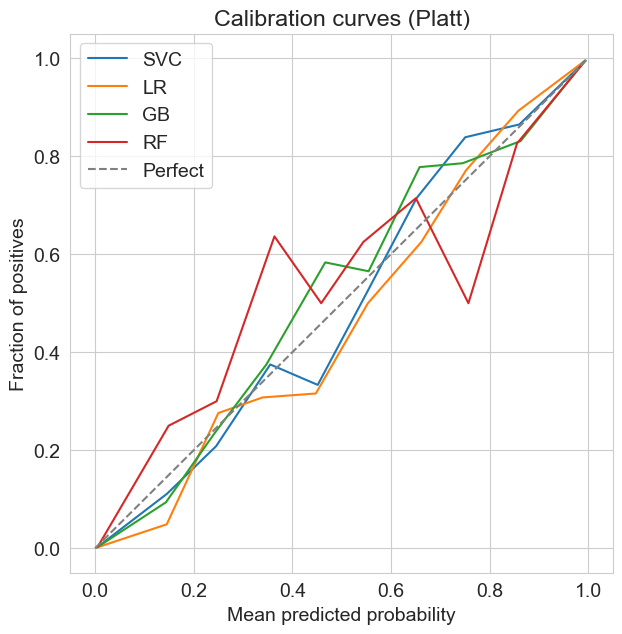

In [38]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', sigmoid_svc_pred), ('LR', sigmoid_lr_pred), ('GB', sigmoid_gb_pred), ('RF', sigmoid_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Platt)')
plt.legend()
plt.show()

Как мы видим, калибровка Платта действительно улучшила вероятности, который получаются у SVC, RF и GB. При этом кривая для логистической регрессии практически не сдвигается. 

# Изотоническая регрессия
В этом методе также строится отображение из предсказаний модели в откалиброванные вероятности. Используется изотоническая функция: неубывающая, кусочно-постоянная; $x$ — выходы алгоритма, $y$ — целевая переменная. 

Мы хотим найти такую функцию $m(t)$: $P(y = 1 | x) = m(f(x))$. Она настраивается под квадратичную ошибку:

$$m = \arg \min_{z} \sum (y_i - z(f(x_i))^2,$$

с помощью специального алгоритма (Pool-Adjacent-Violators Algorithm):

---
*Вход: обучающая выборка — пары (скор модели $f_i$, метка $y_i \in \{0,1\}$), отсортированные по возрастанию $f_i$.*

Для каждой точки $i$ задаём один сегмент: оценка вероятности сегмента $m_{i,i} = y_i$ (метка точки), вес сегмента $w_{i,i} = 1$.

В цикле, пока есть нарушение изотонности — два соседних сегмента $(k, i-1)$ и $(i, l)$, у которых $m_{k,i-1} \geq m_{i,l}$ — объединяем их в один $(k, l)$: новый вес $w_{k,l} = w_{k,i-1} + w_{i,l}$, новая оценка $m_{k,l} = (w_{k,i-1} m_{k,i-1} + w_{i,l} m_{i,l}) / w_{k,l}$; заменяем два старых сегмента одним и повторяем.

*Выход: кусочно-постоянная функция $m(f)$: для любого скора $f$ значение $m(f)$ — это $m_{i,j}$ того сегмента $(i,j)$, в диапазон которого попадает $f$.*

---

В результате калибровки получаем надстройку над нашей моделью, которая применяется поверх предсказаний базовой модели. В случае мультиклассовой классификации каждый класс калибруется отдельно против остальных (one-versus-all), вероятности при предсказании нормируются.

Этот метод более общий, чем калибровка Платта, так как единственное условие для калибровочной функции - чтобы она была изотонической. Этот метод склонен к переобучению, поэтому его рекомендуется применять только для больших выборок.


In [39]:
isotonic_svc = CalibratedClassifierCV(svc, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_svc_pred = isotonic_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, isotonic_svc_pred))

SVC ROC-AUC: 0.9990992249197903


In [40]:
isotonic_lr = CalibratedClassifierCV(lr, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_lr_pred = isotonic_lr.predict_proba(X_test)[:, 1]
print('LR ROC-AUC:', roc_auc_score(y_test, isotonic_svc_pred))

LR ROC-AUC: 0.9990992249197903


In [41]:
isotonic_gb = CalibratedClassifierCV(gb, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_gb_pred = isotonic_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, isotonic_gb_pred))

Gradient Boosting ROC-AUC: 0.998995204210282


In [42]:
isotonic_rf = CalibratedClassifierCV(rf, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_rf_pred = isotonic_rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, isotonic_rf_pred))

Random Forest ROC-AUC: 0.9991284163514756


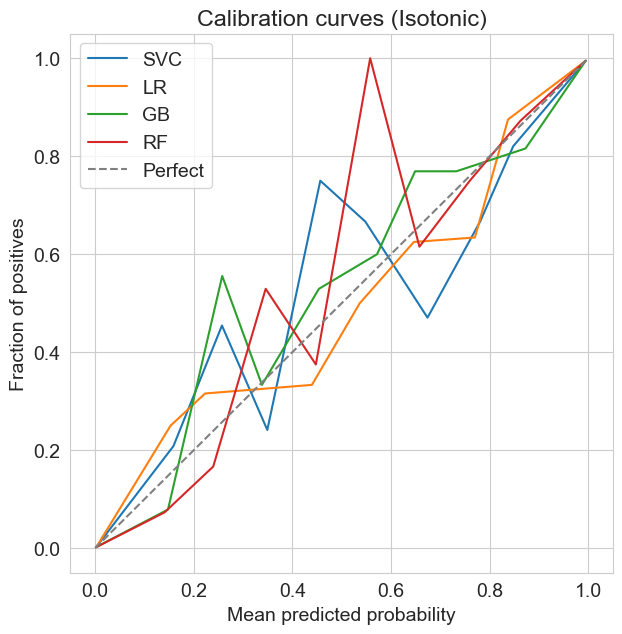

In [43]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', isotonic_svc_pred), ('LR', isotonic_lr_pred), ('GB', isotonic_gb_pred), ('RF', isotonic_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Isotonic)')
plt.legend()
plt.show()

Изотоническая регрессия немного подпортила кривую калибрации для моделей. Судя по всему, олна переобучилась.

## Мультикласс
У нас есть как минимум три варианта определить, что означает мультиклассовая калиброванность. Например, по мере увеличения строгости:
1) Учитывать только самую высокую вероятность. Для него мы требуем, чтобы среди всех случаев, где вероятность наиболее вероятного класса прогнозируется как $c$, ожидаемая точность была бы $c$. $P(Y=i|\hat p_i(x)=q_i)=q_i, i=\arg\max_j \hat p_j (X)$
2) Учитывать маргинальные вероятности. Тут мы хотим, чтобы все one-vs-rest вероятности были откалиброваны: $P(Y=i|\hat p_i(x)=q_i)=q_i, i=1...k$.
3) Учитывать весь вектор вероятностей. Т.е. чтобы пропорции классов для семплов с определенным вектором предсказаний былит такие же, как и весь вектор предсказаний:  $P(Y=i|\hat p(x)=q)=q_i, i=1...k$. 
   
Чаще всего используется определение слабой калиброванности (1). Однако, в случае чувствительной к стоимости постановки задачи оно может быть слишком слабым.


## Оценка качества калибровки

Мы что-то поняли по графикам, но как оценить численно улучшение предсказания вероятностей? Для этого есть свои метрики.

**Maximum calibration error**. Самый простой способ, впрочем — он наследник идеи с калибровочной кривой. А именно, разобьём отрезок 
$[0,1]$ на бины $B_1, B_2, ..., B_k$ по предсказанным вероятностям $\overline y(x_i)$ и вычислим следующее:
$$ \max_{j=1,..,k}|{\overline y(B_k) - \overline q (B_k) }|$$
Где $\overline y(B_k) $ - средняя предсказанная вероятность, $ \overline q (B_k) $ - среднее значение уверенности.

**Expected Calibration Error (ECE)** считает среднюю разницу: $$ \sum^k_{j=1}{{\|B_j\|}\over{N}}{| {\overline y(B_k) - \overline q (B_k) }|},$$
где $\|B_j\|$ - число семплов в бине. Бинны обычно строят равными по длине отрезка $[0,1]$ (uniform) или по квантилям предсказаний (quantile); веса $|B_j|/N$ делают вклад каждого бина пропорциональным его размеру.

Проблема этих способов в том, что мы можем очень по-разному предсказывать в каждом из бинов вероятности (в том числе константой) без ущерба для метрики.

Применим метрику калибрации:

In [44]:
def binary_ECE(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        low, high = bin_edges[i], bin_edges[i + 1]
        mask = (y_prob >= low) & (y_prob <= high) if i == n_bins - 1 else (y_prob >= low) & (y_prob < high)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() * np.abs(acc - conf)
    return ece / n

print("Platt:")
print('SVC binary-ECE = ', binary_ECE(y_test, sigmoid_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, sigmoid_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, sigmoid_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, sigmoid_rf_pred))

print("Isotonic:")
print('SVC binary-ECE = ', binary_ECE(y_test, isotonic_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, isotonic_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, isotonic_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, isotonic_rf_pred))

Platt:
SVC binary-ECE =  0.0027822956798889934
Linear binary-ECE =  0.0034477460600426638
GB binary-ECE =  0.003472623806893145
RF binary-ECE =  0.002610568433671964
Isotonic:
SVC binary-ECE =  0.0020864508068445986
Linear binary-ECE =  0.002150623426981368
GB binary-ECE =  0.002283717139315842
RF binary-ECE =  0.002056138427129562


Может быть такое, что метрики показывают нам иную картину, чем графики. Возможно, дело в том, что мы делали графики без учета числа семплов в бинах (а резкие прыжки могут значить, что семплов маловато). 

**Задание**: постройте калибровочные кривые для адаптивных бинов (strategy=‘quantile’) и сравните графики для разных калибровок с ними.

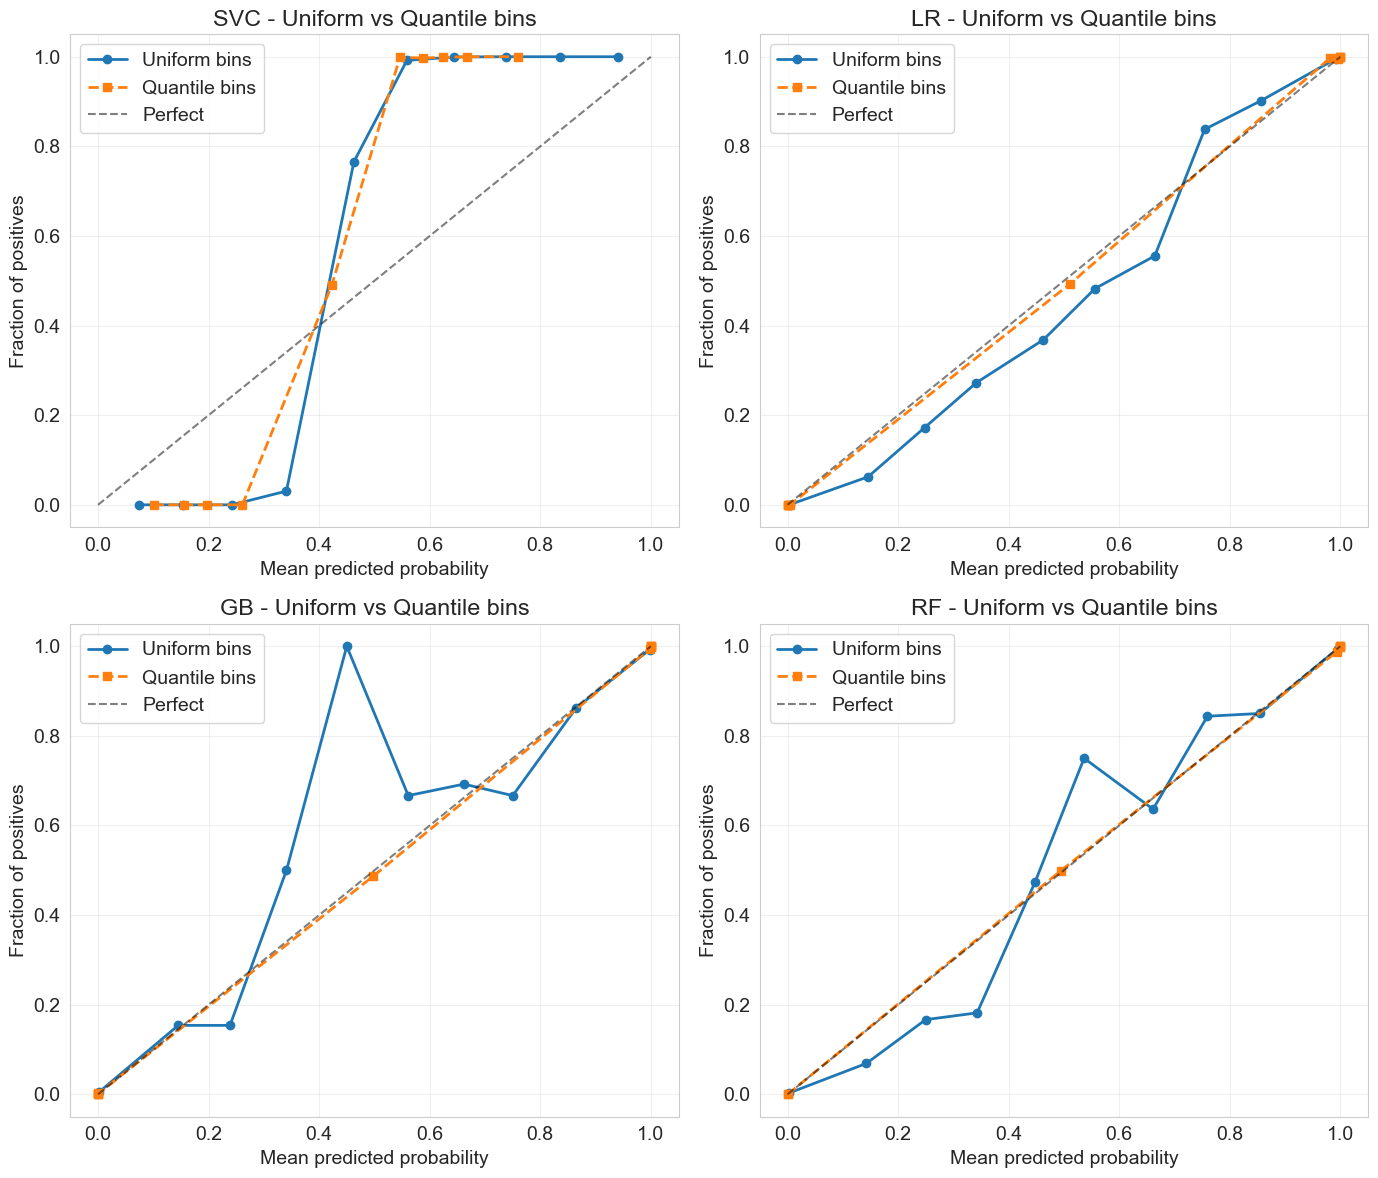

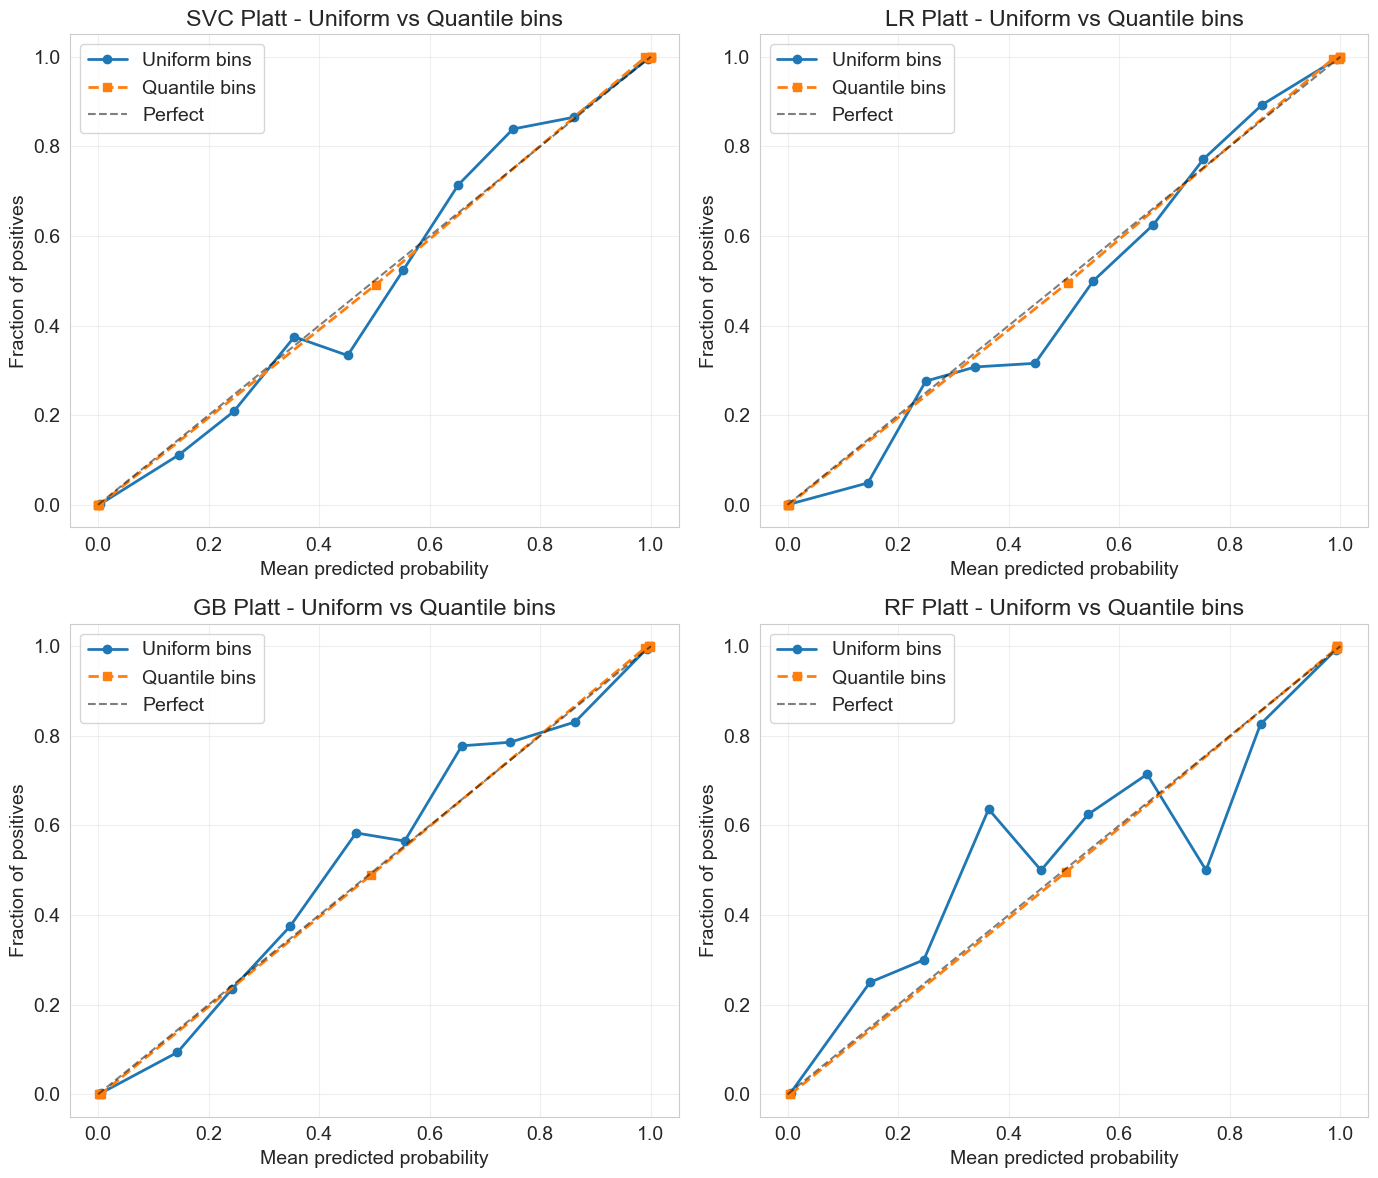

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

methods = [('SVC', svc_pred), ('LR', lr_pred), ('GB', gb_pred), ('RF', rf_pred)]
titles = ['SVC', 'Logistic Regression', 'Gradient Boosting', 'Random Forest']

for idx, (name, pred) in enumerate(methods):
    row, col = idx // 2, idx % 2
    
    true_prob_uni, pred_prob_uni = calibration_curve(y_test, pred, n_bins=10, strategy='uniform')
    true_prob_quant, pred_prob_quant = calibration_curve(y_test, pred, n_bins=10, strategy='quantile')
    
    axs[row, col].plot(pred_prob_uni, true_prob_uni, 'o-', label='Uniform bins', linewidth=2)
    axs[row, col].plot(pred_prob_quant, true_prob_quant, 's--', label='Quantile bins', linewidth=2)
    axs[row, col].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    axs[row, col].set_xlabel('Mean predicted probability')
    axs[row, col].set_ylabel('Fraction of positives')
    axs[row, col].set_title(f'{name} - Uniform vs Quantile bins')
    axs[row, col].legend()
    axs[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(14, 12))

calib_methods = [('SVC Platt', sigmoid_svc_pred), ('LR Platt', sigmoid_lr_pred), 
                 ('GB Platt', sigmoid_gb_pred), ('RF Platt', sigmoid_rf_pred)]

for idx, (name, pred) in enumerate(calib_methods):
    row, col = idx // 2, idx % 2
    
    true_prob_uni, pred_prob_uni = calibration_curve(y_test, pred, n_bins=10, strategy='uniform')
    true_prob_quant, pred_prob_quant = calibration_curve(y_test, pred, n_bins=10, strategy='quantile')
    
    axs[row, col].plot(pred_prob_uni, true_prob_uni, 'o-', label='Uniform bins', linewidth=2)
    axs[row, col].plot(pred_prob_quant, true_prob_quant, 's--', label='Quantile bins', linewidth=2)
    axs[row, col].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    axs[row, col].set_xlabel('Mean predicted probability')
    axs[row, col].set_ylabel('Fraction of positives')
    axs[row, col].set_title(f'{name} - Uniform vs Quantile bins')
    axs[row, col].legend()
    axs[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

In [47]:
from sklearn.metrics import brier_score_loss, log_loss

classifiers = [
    ('SVC', svc_pred),
    ('Logistic Regression', lr_pred),
    ('Gradient Boosting', gb_pred),
    ('Random Forest', rf_pred)
]

for name, pred in classifiers:
    roc_auc = roc_auc_score(y_test, pred)
    brier = brier_score_loss(y_test, pred)
    ll = log_loss(y_test, pred)
    
    print(f"\n{name}:")
    print(f"  ROC-AUC:      {roc_auc:.6f}")
    print(f"  Brier Score:  {brier:.6f}")
    print(f"  Log Loss:      {ll:.6f}")


SVC:
  ROC-AUC:      0.999145
  Brier Score:  0.103584
  Log Loss:      0.368520

Logistic Regression:
  ROC-AUC:      0.999002
  Brier Score:  0.008709
  Log Loss:      0.034384

Gradient Boosting:
  ROC-AUC:      0.998357
  Brier Score:  0.008841
  Log Loss:      0.045925

Random Forest:
  ROC-AUC:      0.999101
  Brier Score:  0.008120
  Log Loss:      0.031454


**Вопрос**: Как можно адаптировать MCE/ECE для мультиклассовой задачи? Напишите формулы.
*Ответ*: использовать выигравший класс. Можно сделать бинарные есе для всех классов и потом усреднить по классам.

В случае мультикласса, у нас возникает несколько сложностей: во-первых, в случае большого числа классов число бинов будет очень большим, при этом многие будут пустыми. Да и само определение реальной ECE пока не сделано. 

**Задание:** посчитайте ECE для модели, которая предсказывает пропорцию классов. Какие знаечения ECE и лосса у нее будут? Что изменится, если модель начнет предсказывать 0.9 для позитивных семплов и продолжит предсказывать пропорцию классов для негадивных?

In [51]:
import numpy as np
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.calibration import calibration_curve

# Модель, предсказывающая пропорцию классов
p_constant = np.full_like(y_test, y_test.mean(), dtype=float)

# Модифицированная модель: 0.9 для позитивных, пропорция для негативных
p_mixed = np.where(y_test == 1, 0.9, y_test.mean())

def calculate_ece(y_true, y_prob, n_bins=10, strategy='uniform'):
    """Расчет Expected Calibration Error"""
    if strategy == 'uniform':
        bins = np.linspace(0, 1, n_bins + 1)
    else:
        bins = np.quantile(y_prob, np.linspace(0, 1, n_bins + 1))
    
    ece = 0
    for i in range(n_bins):
        mask = (y_prob > bins[i]) & (y_prob <= bins[i+1])
        if mask.sum() > 0:
            acc = y_true[mask].mean()
            conf = y_prob[mask].mean()
            ece += np.abs(acc - conf) * mask.mean()
    return ece

print("Модель: константная пропорция классов")
ece_const = calculate_ece(y_test, p_constant)
ll_const = log_loss(y_test, p_constant)
brier_const = brier_score_loss(y_test, p_constant)
print(f"ECE:           {ece_const:.6f}")
print(f"Log Loss:       {ll_const:.6f}")
print(f"Brier Score:   {brier_const:.6f}")

print("Модель: 0.9 для позитивных, пропорция для негативных")

ece_mixed = calculate_ece(y_test, p_mixed)
ll_mixed = log_loss(y_test, p_mixed)
brier_mixed = brier_score_loss(y_test, p_mixed)
print(f"ECE:           {ece_mixed:.6f}")
print(f"Log Loss:       {ll_mixed:.6f}")
print(f"Brier Score:   {brier_mixed:.6f}")

Модель: константная пропорция классов
ECE:           0.000000
Log Loss:       0.688430
Brier Score:   0.247645
Модель: 0.9 для позитивных, пропорция для негативных
ECE:           0.302498
Log Loss:       0.416823
Brier Score:   0.141326


Можно посчитать калиброванность и на уровне семплов.

**Brier score.** Тоже одна из популярных метрик, которая попросту измеряет разницу между предсказанными вероятностями и $ y_i $ (обратите внимание, что $ y_i $  - это либо 0, либо 1):
$$ \sum^N_{i=1}(y_i - q (x_i))^2,$$ 
для бинарного случая, и
$$ {1 \over N} \sum^N_{n=1}\sum^K_{j=1} (I(y_n=j) - q_{nj})^2,$$ 
для мультикласса.

**Вопрос**: Какое значение соответствует лучшей калибрации? Какие максимальные и минимальные значения он можеит принимать?

Ответ: Лучшая калибровка — Brier score = 0. Минимум - 0, максимум: 1

Также можно использовать log-loss:
$$ {-1\over N} {\sum^N_{n=1}\sum^K_{j=1}I(y_n=j)log(q_{n,j})}$$

Для достаточно гладких классификатора и датасета brier score и log-loss будут адекватными средствами оценки, но если нет — возможно всякое.

In [52]:
print('Log-loss (ниже — лучше):')
print('Platt SVC =', log_loss(y_test, np.column_stack([1 - sigmoid_svc_pred, sigmoid_svc_pred])))
print('Platt LR =', log_loss(y_test, np.column_stack([1 - sigmoid_lr_pred, sigmoid_lr_pred])))
print('Platt GB =', log_loss(y_test, np.column_stack([1 - sigmoid_gb_pred, sigmoid_gb_pred])))
print('Platt RF =', log_loss(y_test, np.column_stack([1 - sigmoid_rf_pred, sigmoid_rf_pred])))
print('Isotonic SVC =', log_loss(y_test, np.column_stack([1 - isotonic_svc_pred, isotonic_svc_pred])))
print('Isotonic LR =', log_loss(y_test, np.column_stack([1 - isotonic_lr_pred, isotonic_lr_pred])))
print('Isotonic GB =', log_loss(y_test, np.column_stack([1 - isotonic_gb_pred, isotonic_gb_pred])))
print('Isotonic RF =', log_loss(y_test, np.column_stack([1 - isotonic_rf_pred, isotonic_rf_pred])))

Log-loss (ниже — лучше):
Platt SVC = 0.031276285531666545
Platt LR = 0.0333262455198998
Platt GB = 0.03331647881716411
Platt RF = 0.038908642002126646
Isotonic SVC = 0.030862017939829182
Isotonic LR = 0.033625055910619976
Isotonic GB = 0.03191541409933446
Isotonic RF = 0.0317766445159259


In [53]:
print("Platt:")
print('SVC brier score = ', brier_score_loss(y_test, sigmoid_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, sigmoid_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, sigmoid_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, sigmoid_rf_pred, pos_label=1))

print("Isotonic:")
print('SVC brier score = ', brier_score_loss(y_test, isotonic_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, isotonic_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, isotonic_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, isotonic_rf_pred, pos_label=1))

Platt:
SVC brier score =  0.008190798964847236
Linear brier score =  0.008657533565358946
GB brier score =  0.008325371462496654
RF brier score =  0.008416712034272293
Isotonic:
SVC brier score =  0.008210667087880846
Linear brier score =  0.008753390327467456
GB brier score =  0.008318772289237032
RF brier score =  0.008147859165350083


**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

In [55]:
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
import numpy as np

def calculate_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (y_prob > bins[i]) & (y_prob <= bins[i+1])
        if mask.sum() > 0:
            acc = y_true[mask].mean()
            conf = y_prob[mask].mean()
            ece += np.abs(acc - conf) * mask.mean()
    return ece

classifiers = [
    ('SVC (min-max scaled)', svc_pred),
    ('Logistic Regression', lr_pred),
    ('Gradient Boosting', gb_pred),
    ('Random Forest', rf_pred)
]

for name, pred in classifiers:
    roc_auc = roc_auc_score(y_test, pred)
    brier = brier_score_loss(y_test, pred)
    ll = log_loss(y_test, pred)
    ece = calculate_ece(y_test, pred)
    
    print(f"\n{name}:")
    print(f"  ROC-AUC:              {roc_auc:.6f}")
    print(f"  Brier Score:          {brier:.6f}")
    print(f"  Log Loss:              {ll:.6f}")
    print(f"  ECE (Expected Calibration Error): {ece:.6f}")


SVC (min-max scaled):
  ROC-AUC:              0.999145
  Brier Score:          0.103584
  Log Loss:              0.368520
  ECE (Expected Calibration Error): 0.285346

Logistic Regression:
  ROC-AUC:              0.999002
  Brier Score:          0.008709
  Log Loss:              0.034384
  ECE (Expected Calibration Error): 0.006612

Gradient Boosting:
  ROC-AUC:              0.998357
  Brier Score:          0.008841
  Log Loss:              0.045925
  ECE (Expected Calibration Error): 0.005609

Random Forest:
  ROC-AUC:              0.999101
  Brier Score:          0.008120
  Log Loss:              0.031454
  ECE (Expected Calibration Error): 0.002506


Итак, мы откалибровали наши классификаторы. Теперь мы можем оценить, как поменяются метрики после этого. Так, по идее точность, f1 не должны сильно поменяться, так как вблизи от границы разделения вероятности не должны сильно измениться. Так ли это?
Теперь **вопрос**: Изменится ли после калибрации ROC-AUC и как? Можете ли вы ответить на вопрос без измерений?

Могут измениться на малую величину. Калибровка — это монотонно неубывающая трансформация предсказаний. Порядок объектов по вероятности остаётся точно таким же, а значит ранжирование не меняется. ROC-AUC остаётся неизменным

**Задание**: Обучите дерево решений и случайный лес.

In [57]:
dt = DecisionTreeClassifier(max_depth=5, random_state=SEED).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED).fit(X_train, y_train)

dt_pred = dt.predict_proba(X_test)[:, 1]
rf_pred = rf.predict_proba(X_test)[:, 1]

**Задание**: Откалибройте изотоническим методом. Постройте калибровочные кривые для классификаторов, до и после калибровки.

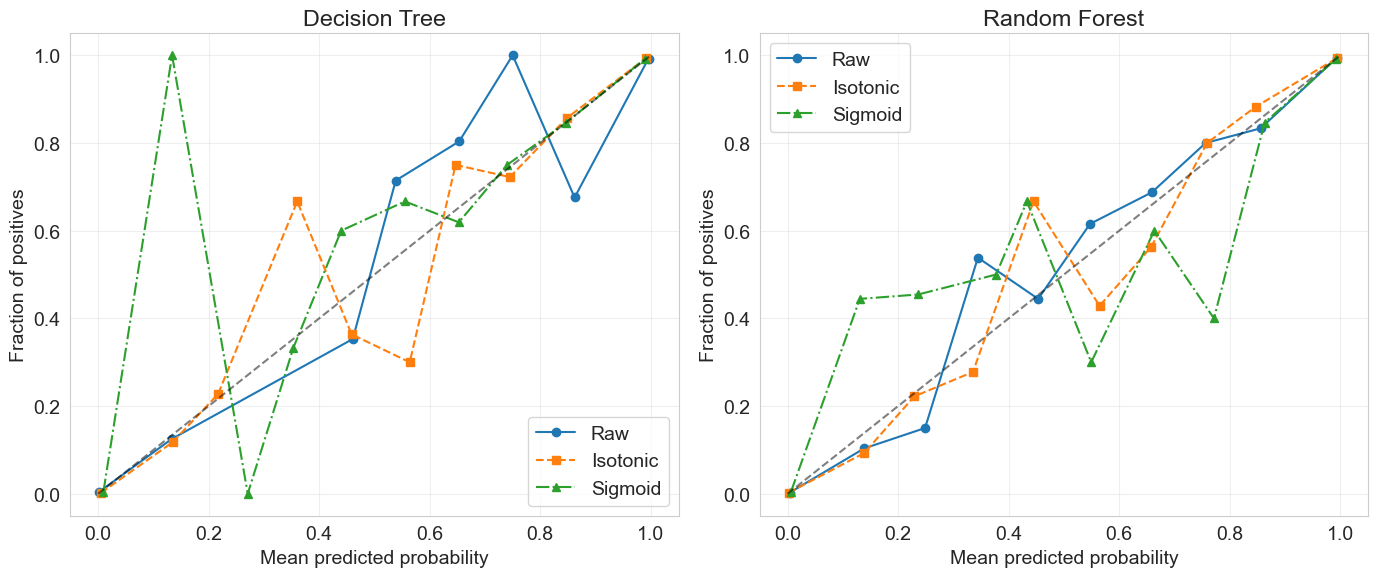

In [ ]:
dt_iso = CalibratedClassifierCV(dt, cv=3, method='isotonic').fit(X_train, y_train)
rf_iso = CalibratedClassifierCV(rf, cv=3, method='isotonic').fit(X_train, y_train)
dt_sig = CalibratedClassifierCV(dt, cv=3, method='sigmoid').fit(X_train, y_train)
rf_sig = CalibratedClassifierCV(rf, cv=3, method='sigmoid').fit(X_train, y_train)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
models = [('Decision Tree', dt_pred, dt_iso, dt_sig), ('Random Forest', rf_pred, rf_iso, rf_sig)]

for ax, (name, p_raw, p_iso, p_sig) in zip(axs, models):
    t_r, p_r = calibration_curve(y_test, p_raw, n_bins=10)
    t_i, p_i = calibration_curve(y_test, p_iso.predict_proba(X_test)[:, 1], n_bins=10)
    t_s, p_s = calibration_curve(y_test, p_sig.predict_proba(X_test)[:, 1], n_bins=10)
    
    ax.plot(p_r, t_r, 'o-', label='Raw')
    ax.plot(p_i, t_i, 's--', label='Isotonic')
    ax.plot(p_s, t_s, '^-.', label='Sigmoid')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title(name)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ВОпрос: Какой вывод можно сделать из графиков?

Ответ: Decision Tree изначально плохо калибрует вероятности, но isotonic-калибровка заметно улучшает результат, тогда как sigmoid ведёт себя нестабильно. Random Forest уже даёт достаточно хорошо откалиброванные вероятности, и калибровка даёт лишь небольшой эффект. В целом, isotonic работает надёжнее, чем sigmoid.

**Задание**: Какой из классификаторов в итоге лучше откалиброван (среди всех)? Покажите в сравнении. Какой вы выберете далее?

In [63]:
def binary_ECE(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (y_prob > bins[i]) & (y_prob <= bins[i+1])
        if mask.sum() > 0:
            ece += np.abs(y_true[mask].mean() - y_prob[mask].mean()) * mask.mean()
    return ece

print("Сравнение ECE:\n")
print(f"{'Модель':<25} {'Isotonic':>10} {'Sigmoid':>10}")
print("-" * 47)

for name, iso_model, sig_model in [
    ('SVC',  sigmoid_svc, sigmoid_svc),  
    ('LR',   sigmoid_lr, sigmoid_lr),
    ('GB',   sigmoid_gb, sigmoid_gb),
    ('DT',   dt_iso, dt_sig),
    ('RF',   rf_iso, rf_sig)
]:
    iso_pred = iso_model.predict_proba(X_test)[:, 1]
    sig_pred = sig_model.predict_proba(X_test)[:, 1]
    print(f"{name:<25} {binary_ECE(y_test, iso_pred):>10.6f} {binary_ECE(y_test, sig_pred):>10.6f}")

Сравнение ECE:

Модель                      Isotonic    Sigmoid
-----------------------------------------------
SVC                         0.002782   0.002782
LR                          0.003448   0.003448
GB                          0.003473   0.003473
DT                          0.003851   0.004323
RF                          0.002378   0.002633


Чем менбше значение тем лучше

Больше информации - в [отличном туториале](https://classifier-calibration.github.io/ecml-pkdd-2020-tutorial/) и [материалах Дьяконова](https://web.archive.org/web/20240315204907/https://alexanderdyakonov.wordpress.com/2020/03/27/%D0%BF%D1%80%D0%BE%D0%B1%D0%BB%D0%B5%D0%BC%D0%B0-%D0%BA%D0%B0%D0%BB%D0%B8%D0%B1%D1%80%D0%BE%D0%B2%D0%BA%D0%B8-%D1%83%D0%B2%D0%B5%D1%80%D0%B5%D0%BD%D0%BD%D0%BE%D1%81%D1%82%D0%B8/).